# One dimensional dummy problem

## Problem Statement

In [32]:
using Ferrite, SparseArrays, WriteVTK, Plots, LinearAlgebra

## Definitions

In [33]:
# constants
R_u = 1.0 # 8.314462618       # J/(mol*K)
M_H2 = 1.0 # 2.01588e-3       # kg/mol
R = 1.0 #R_u / M_H2       # J/(kg*K)
T = 1.0 # 300.0           # K
μ = 1.0 # 8.4e-6          # Pa*s = kg/(m*s)
μϵ = 1.0 # 1.0e-9         # Pa*s = kg/(m*s)  for stabilizing purposes, non-physical, should be as small as possible
C_a = 1.0 # 59.187        # s^-1
p_ref = 1.0e6       # 1MPA
ρ_sat = 5.0 # 7259.0      # kg/m^3
ρ_e = 10.0 # 7164.0        # kg/m^3    initial density solid
E_a = 21179.6       # J/mol
K = 1.0 # 1.0e-9          # m^2, permeability

ϵ = 0.4             # unitless, measure of porosity
A_hoffman = 10.7    # unitless  used for calculating p_eq, the equilibrium pressure, different for desorption
B_hoffman = 3704.6  # K used for calculating p_eq, the equilibrium pressure

# A = C_a * exp(-E_a/(R*T)) * (p_ref/(R*T))^A_t
A_a = 1.0 # C_a * exp(-E_a/(R_u*T))
p_eqa = 15.0 # p_ref * exp(A_hoffman-B_hoffman/T)

p_in = 4.0 * p_eqa
ρ_in = 15.0 # p_in / (R * T)
ρ_eq = 10.0 # p_eqa / (R * T)

println("A_a = ", A_a, " s^-1")
println("p_eqa = ", p_eqa, " Pa")

A_a = 1.0 s^-1
p_eqa = 15.0 Pa


In [34]:
# spacial discretization parameters
L = 0.5     # length of the domain in x-direction
w = 0.2     # width of the domain in y-direction box is from (0, -w) to (L, w)
h1 = 0.1    # width of the inlet in y-direction. Inlet is from (0, -h1) to (0, h1)
Nx = 30
Ny = 20

hx = L / Nx
hy = 2*w / Ny

name = "x. bug finding";

## grid

In [35]:
# generates grid
grid = generate_grid(
    Quadrilateral, 
    (Nx, Ny), 
    Vec((0.0,-w)), 
    Vec((L,w))
)

# generate the same 
qr = QuadratureRule{RefQuadrilateral}(3)
fr = FacetQuadratureRule{RefQuadrilateral}(2)

# rho, rho_s, and v
ip_rho = Lagrange{RefQuadrilateral, 1}()
cellvalues_rho = CellValues(qr, ip_rho);

ip_rho_s = Lagrange{RefQuadrilateral, 1}()
cellvalues_rho_s = CellValues(qr, ip_rho_s);

ip_v = Lagrange{RefQuadrilateral, 1}()^2
cellvalues_v = CellValues(qr, ip_v);

# facet interpolation for the boundary conditions
ip_f = Lagrange{RefQuadrilateral, 1}()
fqr = FacetQuadratureRule{RefQuadrilateral}(1)
facetvalues = FacetValues(Float64, fqr, ip_f)
facetvalues_v = FacetValues(fqr, ip_v)          # because the velocity is a vector

#create left_slit
addfacetset!(
    grid,
    "left_slit",
    x -> abs(x[1]) < 1e-8 && -h1-1e-8 <= x[2] <= h1+1e-8
)
    
# other boundaries
addfacetset!(
    grid,
    "no_slip_boundaries",
    x ->
        (
            abs(x[1]) < 1e-8 &&
            (x[2] <= -h1 || x[2] >= h1)
        ) ||                            # left boundary excluding the slit
        abs(x[1] - L) < 1e-8 ||         # right boundary
        abs(x[2] + w) < 1e-8 ||         # bottom boundary
        abs(x[2] - w) < 1e-8            # top boundary
)

Grid{2, Quadrilateral, Float64} with 600 Quadrilateral cells and 651 nodes

In [36]:
# degree of freedom handler
dh = DofHandler(grid)
add!(dh, :v,   ip_v)
add!(dh, :rho, ip_rho)
add!(dh, :rho_s, ip_rho_s)
close!(dh);

In [ ]:
# linear constraint handler
ch_lin = ConstraintHandler(dh)

τ = 1e-2
no_slip = Dirichlet(
    :v,
    getfacetset(grid, "no_slip_boundaries"),
    (x, t) -> Vec((0.0, 0.0))
)
rho_inlet = Dirichlet(
    :rho,
    getfacetset(grid, "left_slit"),
    (x, t) -> ρ_eq + (ρ_in - ρ_eq) * (1 - exp(-t/τ))
)
add!(ch_lin, no_slip)
add!(ch_lin, rho_inlet)
close!(ch_lin)

update!(ch_lin, 0.0)

In [38]:
# for debugging purpuses

const rho_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho)]
    for cell in CellIterator(dh)
]...)))

const v_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:v)]
    for cell in CellIterator(dh)
]...)));

const rho_s_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho_s)]
    for cell in CellIterator(dh)
]...)));

$$(M_{\rho})_{ij}=\int \phi^i\phi^j\,dx$$

In [39]:
function doassemble_M!(
    M_rho::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    cellvalues_rho_s::CellValues,
    cellvalues_v::CellValues,
    dh::DofHandler
    )

    # number of basis functions per field, initialize Me
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    n_basefuncs_rho_s  = getnbasefunctions(cellvalues_rho_s)
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)

    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Me = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(M_rho)
    rho_dofs = dof_range(dh, :rho)
    rhos_dofs  = dof_range(dh, :rho_s)
    v_dofs = dof_range(dh, :v)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for rho
        cell_dofs = celldofs(cell)
        fill!(Me,0)
        
        # rho
        Ferrite.reinit!(cellvalues_rho, cell)
        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)
            for i in 1:n_basefuncs_rho
                psi_i = shape_value(cellvalues_rho, q_point, i)
                for j in 1:n_basefuncs_rho
                    psi_j = shape_value(cellvalues_rho, q_point, j)
                    # pim pam pet
                    Me[rho_dofs[i], rho_dofs[j]] += ϵ * psi_i * psi_j * dx
                end
            end
        end

        # rhos
        Ferrite.reinit!(cellvalues_rho_s, cell)
        for q_point in 1:getnquadpoints(cellvalues_rho_s)
            dx = getdetJdV(cellvalues_rho_s, q_point)
            for i in 1:n_basefuncs_rho_s
                psi_i = shape_value(cellvalues_rho_s, q_point, i)
                for j in 1:n_basefuncs_rho_s
                    psi_j = shape_value(cellvalues_rho_s, q_point, j)
                    # pim pam pet
                    Me[rhos_dofs[i], rhos_dofs[j]] += (1-ϵ) * psi_i * psi_j * dx
                end
            end
        end

        # v
        Ferrite.reinit!(cellvalues_v, cell)
        for q_point in 1:getnquadpoints(cellvalues_v)
            dx = getdetJdV(cellvalues_v, q_point)
            for i in 1:n_basefuncs_v
                psi_i = shape_value(cellvalues_v, q_point, i)
                for j in 1:n_basefuncs_v
                    psi_j = shape_value(cellvalues_v, q_point, j)
                    # pim pam pet
                    Me[v_dofs[i], v_dofs[j]] += dot(psi_i, psi_j) * dx
                end
            end
        end        

        assemble!(assembler, cell_dofs, Me)
    end
    return M_rho
end


doassemble_M! (generic function with 1 method)

$$D_{ij} = -\mu\int (\partial_x \phi^i)(\partial_x \phi^j)dx$$

In [40]:
function doassemble_D!(
    D::SparseMatrixCSC, 
    cellvalues_v::CellValues, 
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    De = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(D)
    v_dofs = dof_range(dh, :v)
    
    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(De,0)
        
        Ferrite.reinit!(cellvalues_v, cell)

        for q_point in 1:getnquadpoints(cellvalues_v)
            dx = getdetJdV(cellvalues_v, q_point)

            for i in 1:n_basefuncs_v
                dpsi_i = shape_gradient(cellvalues_v, q_point, i)

                for j in 1:n_basefuncs_v
                    dpsi_j = shape_gradient(cellvalues_v, q_point, j)

                    De[v_dofs[i], v_dofs[j]] += -μ * dpsi_i ⊡ dpsi_j * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, De)
    end
    return D
end


doassemble_D! (generic function with 1 method)

$$D^p_{ij} = -\epsilon\int (\partial_x \phi^i)(\partial_x \phi^j)dx$$

In [41]:
function doassemble_Dp!(
    Dp::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Dpe = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(Dp)
    rho_dofs = dof_range(dh, :rho)
    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(Dpe,0)
        
        Ferrite.reinit!(cellvalues_rho, cell)

        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)

            for i in 1:n_basefuncs_rho
                dpsi_i = shape_gradient(cellvalues_rho, q_point, i)

                for j in 1:n_basefuncs_rho
                    dpsi_j = shape_gradient(cellvalues_rho, q_point, j)

                    Dpe[rho_dofs[i], rho_dofs[j]] += -μϵ * dot(dpsi_i, dpsi_j) * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Dpe)
    end
    return Dp
end


doassemble_Dp! (generic function with 1 method)

In [42]:
struct RHSparams
    A_a::Float64
    R::Float64
    T::Float64
    p_eqa::Float64
    rho_sat::Float64
    dh::DofHandler
    cellvalues_rhog::CellValues
    cellvalues_rhos::CellValues
    cellvalues_v::CellValues
    facetvalues::FacetValues
    M::SparseMatrixCSC          # {Float64,Int} ?
    ML::SparseMatrixCSC         # Linear part of mass Matrix
    rhs::Vector{Float64}        # Can start as zeros, but we do not want to allocate each time step, so we will reuse it
    rhsL::SparseMatrixCSC       # Linear part of right-hand side
    assemble_mass!::Function    # Complete assembly of the mass matrix, including the nonlinear part
    assemble_rhs!::Function     # Complete assembly of the right-hand side, including the nonlinear part
    ch_lin::ConstraintHandler
end

In [43]:
function assemble_mass!(
        M::SparseMatrixCSC,
        u::Vector{Float64},
        params::RHSparams
    )

    copyto!(M, params.ML)  # set M equal to the linear part of the mass matrix, which is constant in time
    return M
end

assemble_mass! (generic function with 1 method)

In [44]:
function assemble_rhs!(
    N::Vector{Float64},
    u::Vector{Float64},
    params::RHSparams
)

    N .= params.rhsL * u     
    return N
end

assemble_rhs! (generic function with 1 method)

In [45]:
# State vectors
ndofs_total = ndofs(dh)
u      = zeros(ndofs_total)
du     = similar(u)
du    .= 0.0
rhs    = similar(u)

# Initialization of matrices
# Assemble linear matrices
ML    = allocate_matrix(dh)
M     = allocate_matrix(dh)
D     = allocate_matrix(dh)
Dp    = allocate_matrix(dh)
rhsL  = allocate_matrix(dh)

doassemble_M!(ML, cellvalues_rho, cellvalues_rho_s, cellvalues_v, dh)
doassemble_D!(D, cellvalues_v, dh)
doassemble_Dp!(Dp, cellvalues_rho, dh)

# Linear parts of rhs
rhsL .= D + Dp

# Initial condition
apply_analytical!(u, dh, :rho, x -> ρ_eq)
apply_analytical!(u, dh, :rho_s, x -> ρ_e)
apply_analytical!(u, dh, :v,   x -> Vec(0.0, 0.0))

# Initial BC application
update!(ch_lin, 0.0)
apply!(u, ch_lin);

In [46]:
params = RHSparams(
    A_a, 
    R, 
    T, 
    p_eqa, 
    ρ_sat, 
    dh, 
    cellvalues_rho, 
    cellvalues_rho_s, 
    cellvalues_v,
    facetvalues,
    M,
    ML,
    rhs,
    rhsL,
    assemble_mass!,
    assemble_rhs!,
    ch_lin,
)

RHSparams(1.0, 1.0, 1.0, 15.0, 5.0, DofHandler{2, Grid{2, Quadrilateral, Float64}}(SubDofHandler{DofHandler{2, Grid{2, Quadrilateral, Float64}}}[SubDofHandler{DofHandler{2, Grid{2, Quadrilateral, Float64}}}(DofHandler{2, Grid{2, Quadrilateral, Float64}}(#= circular reference @-3 =#), OrderedCollections.OrderedSet{Int64}([1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  591, 592, 593, 594, 595, 596, 597, 598, 599, 600]), [:v, :rho, :rho_s], Interpolation[VectorizedInterpolation{2, RefQuadrilateral, 1, Lagrange{RefQuadrilateral, 1}}(Lagrange{RefQuadrilateral, 1}()), Lagrange{RefQuadrilateral, 1}(), Lagrange{RefQuadrilateral, 1}()], Int64[], 16)], [:v, :rho, :rho_s], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  2597, 2598, 2475, 2479, 2603, 2599, 2476, 2480, 2604, 2600], [1, 17, 33, 49, 65, 81, 97, 113, 129, 145  …  9441, 9457, 9473, 9489, 9505, 9521, 9537, 9553, 9569, 9585], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  1, 1, 1, 1, 1, 1, 1, 1, 1, 1], true, Grid{2, Quadrilateral, Float64}(Quadrilateral[Quadrilateral((1, 2, 3

In [47]:
function res!(res, du, u, params, t)

    params.assemble_mass!(params.M, u, params)
    params.assemble_rhs!(params.rhs, u, params)

    mul!(res, params.M, du)      # res = M*du
    res .-= params.rhs

    # linear constraints
    update!(params.ch_lin, t)
    for k in 1:length(params.ch_lin.prescribed_dofs)

        dof = params.ch_lin.prescribed_dofs[k]
        value = params.ch_lin.inhomogeneities[k]

        res[dof] = u[dof] - value
        
    end
end


res! (generic function with 1 method)

In [48]:
drho_bc_dt = (ρ_in - ρ_eq) / τ

5000.0

In [49]:
params.assemble_mass!(params.M, u, params)
params.assemble_rhs!(params.rhs, u, params)

A0 = copy(params.M)
b0 = copy(params.rhs)

# ramped rho inlet. Derivative at inlet t=0
drho_bc_dt = (ρ_in - ρ_eq) / τ

# no-slip velocity BCs: prescribed velocity is constant zero
for k in 1:length(params.ch_lin.prescribed_dofs)
    dof = params.ch_lin.prescribed_dofs[k]

    A0[dof, :] .= 0.0
    A0[dof, dof] = 1.0

    if dof in v_global
        b0[dof] = 0.0
    else
        println("dof = ", dof, " is not a velocity dof, setting b0[dof] = drho_bc_dt = ", drho_bc_dt)
        b0[dof] = drho_bc_dt
    end
end

du .= A0 \ b0;

dof = 626 is not a velocity dof, setting b0[dof] = drho_bc_dt = 5000.0
dof = 750 is not a velocity dof, setting b0[dof] = drho_bc_dt = 5000.0
dof = 874 is not a velocity dof, setting b0[dof] = drho_bc_dt = 5000.0
dof = 998 is not a velocity dof, setting b0[dof] = drho_bc_dt = 5000.0
dof = 1122 is not a velocity dof, setting b0[dof] = drho_bc_dt = 5000.0
dof = 1246 is not a velocity dof, setting b0[dof] = drho_bc_dt = 5000.0
dof = 1370 is not a velocity dof, setting b0[dof] = drho_bc_dt = 5000.0
dof = 1494 is not a velocity dof, setting b0[dof] = drho_bc_dt = 5000.0
dof = 1618 is not a velocity dof, setting b0[dof] = drho_bc_dt = 5000.0
dof = 1742 is not a velocity dof, setting b0[dof] = drho_bc_dt = 5000.0
dof = 1866 is not a velocity dof, setting b0[dof] = drho_bc_dt = 5000.0


In [50]:
du[rho_global]

651-element Vector{Float64}:
 -13.812154696152929
   3.7009556965260826
  -7.401911393191891
  27.624309392315773
  -0.9916680900980547
   1.983336180265493
   0.2657166638646168
  -0.5314333277471389
  -0.07119856552835853
   0.14239713093905057
   0.01907759814952618
  -0.03815519617019328
  -0.005111827083881719
   ⋮
   2.273421144828846e-10
   1.3619577925357858e-10
  -8.190753626591793e-11
   4.230815247204422e-11
  -3.2747772277158655e-11
   1.1446356472433954e-10
  -1.4006108296661128e-10
   1.8880989355126103e-10
  -1.35384656851012e-10
  -7.104070747726556e-12
   1.9578804733595084e-11
  -1.0245745865713888e-10

In [51]:
res_test  = similar(u)
res!(res_test, du, u, params, 0.0)
res_test[626]

0.0

In [52]:
using DifferentialEquations, Sundials

In [53]:
using BenchmarkTools

In [54]:
differential_vars = trues(length(u))

# the bc are not of the form du/dt = f(u), but rather f(u) = 0. So we need to set the differential_vars of the prescribed dofs to false
for dof in ch_lin.prescribed_dofs
    differential_vars[dof] = false
end

tspan = (0.0, 1e-1)


prob = DAEProblem(
    res!,
    du,
    u,
    tspan,
    params;
    differential_vars=differential_vars
)

sol = solve(
    prob, 
    IDA(),
    saveat=5e-3, 
    reltol=1e-6, 
    abstol=1e-6,
)

retcode: Success
Interpolation: 1st order linear
t: 21-element Vector{Float64}:
 0.0
 0.005
 0.01
 0.015
 0.02
 0.025
 0.03
 0.035
 0.04
 0.045
 0.05
 0.055
 0.06
 0.065
 0.07
 0.075
 0.08
 0.085
 0.09
 0.095
 0.1
u: 21-element Vector{Vector{Float64}}:
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 10.0  …  10.0, 10.0, 0.0, 0.0, 10.0, 10.0, 0.0, 0.0, 10.0, 10.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 12.00889501227397, 11.982123158696156  …  10.004791850690097, 10.0, 0.0, 0.0, 10.003923258818956, 10.0, 0.0, 0.0, 10.003643706216957, 10.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 12.975816436672659, 12.95208549589453  …  10.13975690078878, 10.0, 0.0, 0.0, 10.131974775604702, 10.0, 0.0, 0.0, 10.12939598756412, 10.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 13.381024672527907, 13.360581953033986  …  10.456250929157683, 10.0, 0.0, 0.0, 10.444178166950158, 10.0, 0.0, 0.0, 10.440158849088451, 10.0]
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 13.617066544636614, 13.599069342686834  …  10.8

In [24]:
sol.alg

IDA{:Dense, Nothing, Nothing}(0, 0, 0, 5, 7, 0.33, 3, 10, 0.0033, 5, 4, 10, 100, true, false, nothing, nothing)

In [55]:
sol.destats

SciMLBase.DEStats
Number of function 1 evaluations:                  153
Number of function 2 evaluations:                  0
Number of W matrix evaluations:                    22
Number of linear solves:                           0
Number of Jacobians created:                       22
Number of nonlinear solver iterations:             153
Number of nonlinear solver convergence failures:   0
Number of fixed-point solver iterations:           0
Number of fixed-point solver convergence failures: 0
Number of rootfind condition calls:                0
Number of accepted steps:                          128
Number of rejected steps:                          2

## Plotting/animating

In [26]:
using Plots

In [56]:
xs = [node.x[1] for node in getnodes(grid)]
ys = [node.x[2] for node in getnodes(grid)]

# Find global plotting limits first
rho_min  = Inf
rho_max  = -Inf
rhos_min = Inf
rhos_max = -Inf

for uk in sol.u
    rho_nodes  = evaluate_at_grid_nodes(dh, uk, :rho)
    rhos_nodes = evaluate_at_grid_nodes(dh, uk, :rho_s)

    rho_min  = min(rho_min, minimum(rho_nodes))
    rho_max  = max(rho_max, maximum(rho_nodes))

    rhos_min = min(rhos_min, minimum(rhos_nodes))
    rhos_max = max(rhos_max, maximum(rhos_nodes))
end

anim = @animate for k in eachindex(sol.t)

    rho_nodes  = evaluate_at_grid_nodes(dh, sol.u[k], :rho)
    rhos_nodes = evaluate_at_grid_nodes(dh, sol.u[k], :rho_s)

    p1 = scatter(
        xs,
        ys,
        marker_z = rho_nodes,
        markersize = 6,
        markerstrokewidth = 0,
        color = :viridis,
        colorbar = true,
        clims = (rho_min, rho_max),
        xlabel = "x",
        ylabel = "y",
        aspect_ratio = :equal,
        title = "ρ_g at t = $(round(1000sol.t[k], digits=5)) ms",
        legend = false,
        xlims = (0, L),
        ylims = (-w, w),
    )

    p2 = scatter(
        xs,
        ys,
        marker_z = rhos_nodes,
        markersize = 6,
        markerstrokewidth = 0,
        color = :viridis,
        colorbar = true,
        clims = (rhos_min, rhos_max),
        xlabel = "x",
        ylabel = "y",
        aspect_ratio = :equal,
        title = "ρ_s",
        legend = false,
        xlims = (0, L),
        ylims = (-w, w),
    )

    plot(p1, p2, layout=(2,1), size=(800,600))
end


GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is inval

Animation("C:\\Users\\noudh\\AppData\\Local\\Temp\\jl_tAEef8", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000012.png", "000013.png", "000014.png", "000015.png", "000016.png", "000017.png", "000018.png", "000019.png", "000020.png", "000021.png"])

[ Info: Saved animation to c:\Users\noudh\uni\MEP\Model 5\x. bug finding\2.gif


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\Model 5\\x. bug finding\\2.gif")
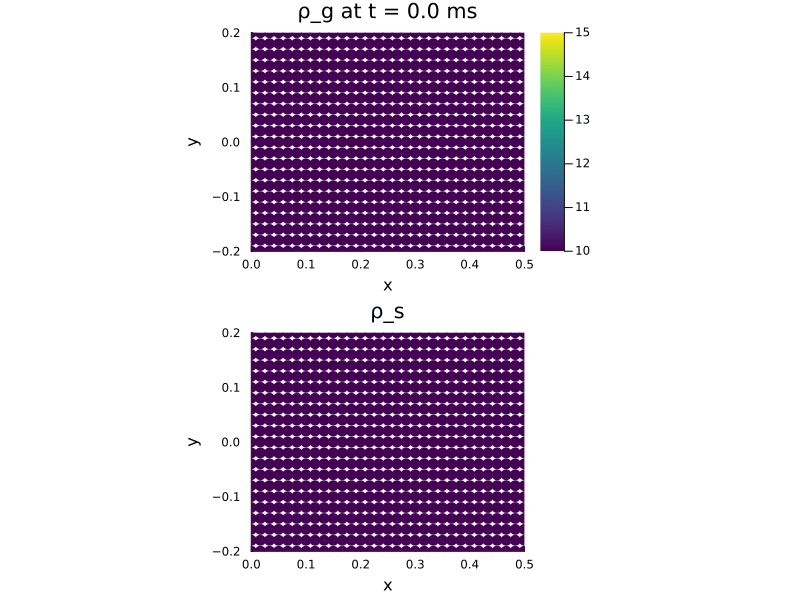

In [57]:
foldername = "x. bug finding"
gif(anim, joinpath(foldername, "2.gif"), fps=10)

In [74]:
# double gif plot
foldername = name

U = Array(sol)

xs = [node.x[1] for node in getnodes(grid)]
ys = [node.x[2] for node in getnodes(grid)]

sol_v = U[v_global, :]
sol_ρ = U[rho_global, :]
sol_ρ_s = U[rho_s_global, :]

discrete_x = range(0.0, 1.0, length=size(sol_ρ, 1))
discrete_t = sol.t #range(dt_save, step=dt_save, length=size(sol_ρ, 2))

ρmax = maximum(sol_ρ)
ρmin = minimum(sol_ρ)

rhosmin = minimum(sol_ρ_s)
rhosmax = maximum(sol_ρ_s)

vmax = maximum(sol_v)
vmin = minimum(sol_v)

anim = @animate for k in 1:length(sol.t)-2

    p1 = scatter(
        xs, ys,
        marker_z = sol_ρ[:, k],
        markersize = 6,
        markerstrokewidth = 0,
        color = :viridis,
        colorbar = true,
        clims = (ρmin, ρmax),
        xlabel = "x",
        ylabel = "y",
        aspect_ratio = :equal,
        title="ρ_g at t = $(round(1000*discrete_t[k], digits=5))ms",
        legend = false,
        xlims = (0, L),
        ylims = (-w, w)
    )

    p2 = scatter(
        xs, ys,
        marker_z = sol_ρ_s[:, k],
        markersize = 6,
        markerstrokewidth = 0,
        color = :viridis,
        colorbar = true,
        clims = (rhosmin, rhosmax),
        xlabel = "x",
        ylabel = "y",
        title = "ρ_s",
        aspect_ratio = :equal,
        xlims = (0, L),
        ylims = (-w, w),
        legend = false
    )

    plot(p1, p2, layout=(2,1), size=(800,600))
end

GKS: Possible loss of precision in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin outside current window
GKS: Rectangle definition is invalid in routine SET_WINDOW
GKS: Rectangle definition is invalid in routine CELLARRAY
invalid range
origin out

Animation("C:\\Users\\noudh\\AppData\\Local\\Temp\\jl_rUM9Qp", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png", "000011.png", "000012.png", "000013.png", "000014.png", "000015.png", "000016.png", "000017.png", "000018.png", "000019.png"])

[ Info: Saved animation to c:\Users\noudh\uni\MEP\Model 5\x. bug finding\2.gif


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\Model 5\\x. bug finding\\2.gif")
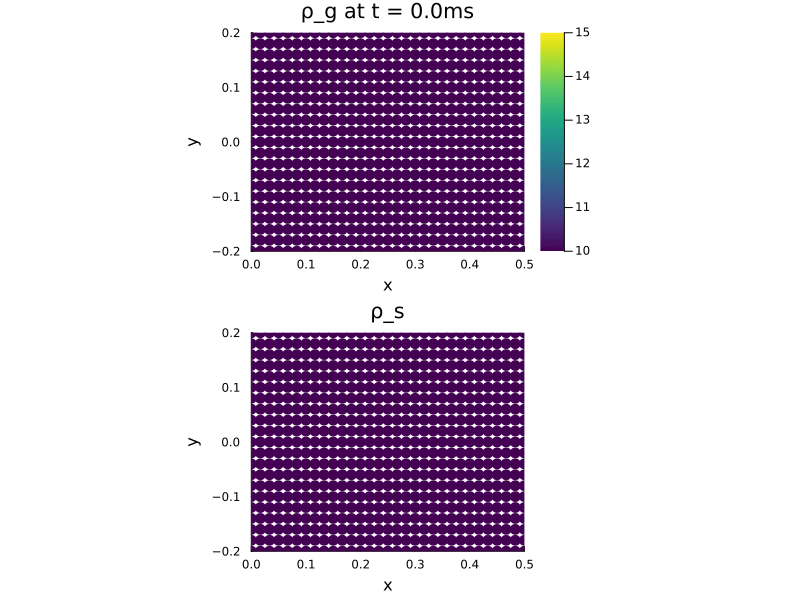

In [75]:
gif(anim, joinpath(foldername, "2.gif"), fps=10)

In [105]:
using Ferrite
using WriteVTK

name = "xbug finding"

output_dir = "vtk_" * name
mkpath(output_dir)

pvd = paraview_collection(joinpath(output_dir, name))

for (k, t) in enumerate(sol.t)

    filename = joinpath(
        output_dir,
        "$(name)_$(lpad(k, 5, '0'))"
    )

    VTKGridFile(filename, dh) do vtk

        write_solution(vtk, dh, sol.u[k])

        # add this timestep to the PVD collection
        pvd[t] = vtk
    end
end

vtk_save(pvd)

12-element Vector{String}:
 "vtk_xbug finding\\xbug finding.pvd"
 "vtk_xbug finding\\xbug finding_00001.vtu"
 "vtk_xbug finding\\xbug finding_00002.vtu"
 "vtk_xbug finding\\xbug finding_00003.vtu"
 "vtk_xbug finding\\xbug finding_00004.vtu"
 "vtk_xbug finding\\xbug finding_00005.vtu"
 "vtk_xbug finding\\xbug finding_00006.vtu"
 "vtk_xbug finding\\xbug finding_00007.vtu"
 "vtk_xbug finding\\xbug finding_00008.vtu"
 "vtk_xbug finding\\xbug finding_00009.vtu"
 "vtk_xbug finding\\xbug finding_00010.vtu"
 "vtk_xbug finding\\xbug finding_00011.vtu"

In [60]:
getfacetset(grid, "left_slit")

OrderedCollections.OrderedSet{FacetIndex} with 6 elements:
  FacetIndex((121, 4))
  FacetIndex((145, 4))
  FacetIndex((169, 4))
  FacetIndex((193, 4))
  FacetIndex((217, 4))
  FacetIndex((241, 4))

In [ ]:
# We calculate the FE integration weights for rho_s.
#
# The mass matrix is:
#
#     M_ij = ∫ phi_i * phi_j dx
#
# Multiplying it by a vector of ones gives:
#
#     b_i = Σ_j M_ij = ∫ phi_i dx
#
# which is the correct FE weight for integrating the solution:
#
#     ∫ rho_s dx ≈ b ⋅ rho_s
#
# This automatically handles the dx/2 boundary contributions
# for P1 elements and also works for nonuniform meshes.
M_rho_s = ML[rho_s_global, rho_s_global]
mass_weights_rho_s = M_rho_s * ones(length(rho_s_global))


# Calculate total absorbed amount at every saved timestep
absorbed_mass = zeros(size(sol_ρ_s, 2))

for k in axes(sol_ρ_s, 2)

    # FE approximation of:
    #
    #     M_s(t) = ∫ rho_s(x,t) dx
    #
    absorbed_mass[k] = dot(mass_weights_rho_s, sol_ρ_s[:, k])

end


# Maximum possible absorbed mass:
#
#     M_sat = ∫ rho_sat dx = rho_sat * L
#
# Here L = 1, but keeping the formula general.

maximum_mass = rho_sat * 1.0


# Fraction of solid capacity filled
fill_fraction = absorbed_mass ./ maximum_mass


# Plot filling fraction versus time
plot(
    discrete_t,
    fill_fraction,
    xlabel = "time",
    ylabel = "fraction filled",
    label = "solid saturation",
)

In [ ]:
plot(
    sol.t,
    sol_ρ_s[1, :],
    xlabel = "time (s)",
    ylabel = "saturation",
    label = "saturation at x=0",
    legend=:bottomright
)
k = log(2)/(1-ϵ)
plot!(
    sol.t,
    1.0 .- 1 .* exp.(-k.*sol.t),
    label = "analytical solution at x=0",
    linestyle = :dash
)

plot!(
    sol.t,
    fill_fraction/(1-ϵ),
    # xlabel = "time",
    # ylabel = "fraction filled",
    label = "full solid saturation"
    )

plot!(
    sol.t,
    sol_ρ_s[end, :],
    # xlabel = "time",
    # ylabel = "solid density [kg/m^3]",
    label = "saturation at x=L"
)


In [ ]:
savefig(joinpath(foldername, "fill_fraction total pressure.png"))

In [ ]:
# report_figures_folder = "..\\report\\figures\\"
# folder = mkpath(report_figures_folder)
# name = "A.png"
# savefig(joinpath(folder, name))